# Getting started: discover a PDE from field data

This notebook walks through a compact PDE discovery workflow with kd. We will load a bundled Burgers benchmark with a known equation, inspect the field data, fit a symbolic model in one call, and compare the discovered equation with the ground truth. The final cell keeps the visualization inline so the notebook renders well on GitHub.

In [1]:
import kd

ds = kd.load_burgers()
print(ds.ground_truth)

u_t = -u * u_x + 0.1 * u_xx


## Look at the data

The dataset contains a field `u` sampled on an `(x, t)` grid. Before fitting, `kd.preview` prints the grid, field, and left-hand-side derivative that kd will use.

Dataset: burgers
Axes:
     x | n=256  | range [-8.000, 7.938] | step 0.0625 (uniform)
     t | n=201  | range [0.000, 10.000] | step 0.05 (uniform)
Fields:
     u | dtype=float64 | shape=(256, 201) | min=-1.000 max=1.000 mean=0.000 (NaN=0)
LHS: u_t  (field='u', axis='t')
Status: ready to fit


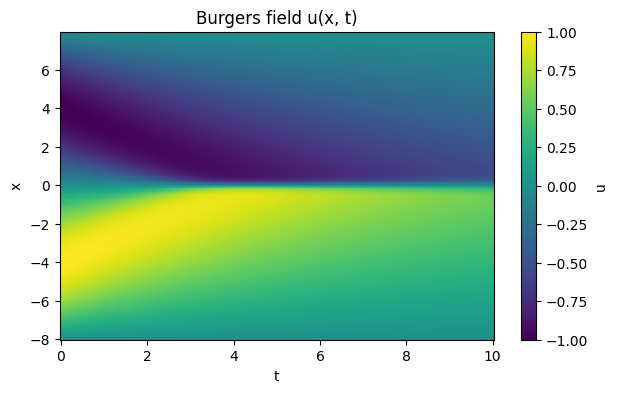

In [2]:
import matplotlib.pyplot as plt

kd.preview(ds)

field = ds.get_field(ds.lhs_field).detach().cpu().numpy()
x = ds.get_coords("x")
t = ds.get_coords("t")

fig, ax = plt.subplots(figsize=(7, 4))
mesh = ax.pcolormesh(t, x, field, shading="auto", cmap="viridis")
ax.set_xlabel("t")
ax.set_ylabel("x")
ax.set_title("Burgers field u(x, t)")
fig.colorbar(mesh, ax=ax, label="u")
plt.show()

## Fit a model

SGA searches over symbolic expression trees and scores candidate right-hand sides against the target derivative. The `generations` value is the search budget, so this tutorial uses a small deterministic budget that is still enough to recover a Burgers-like equation.

In [3]:
model = kd.Model(algorithm="sga", generations=5, seed=0, verbose=False).fit(ds)
print(model.best_expr_)
print(model.best_score_)

u_t = -1*mul(u_x, u) + 0.1002*diff2_x(u)
-28.776750720652373


## Compare to ground truth

Read the discovered equation as kd's best symbolic right-hand side for `u_t`. The exact string can differ from the compact textbook form, but the useful check is whether it captures the nonlinear advection and diffusion terms.

In [4]:
print(f"Discovered  : {model.best_expr_}")
print(f"Ground truth: {ds.ground_truth}")

Discovered  : u_t = -1*mul(u_x, u) + 0.1002*diff2_x(u)
Ground truth: u_t = -u * u_x + 0.1 * u_xx


## Visualize

`kd.viz.plots.plot_convergence` draws the best-score curve straight from the
fitted result. It reads the recorded score series, masks the non-finite
warm-up sentinel so the y axis stays readable, labels that axis with the
engine's own score kind (AIC for SGA), and adds a subtitle when the curve is
flat (best score reached on the first iteration). The return value is a list
of warning strings, empty when the curve was drawn.

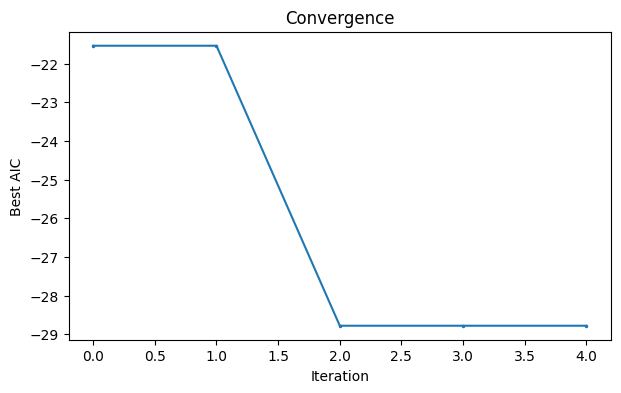

In [5]:
from kd.viz.plots import plot_convergence

fig, ax = plt.subplots(figsize=(7, 4))
messages = plot_convergence(model.result_, ax)
for message in messages:
    print(message)
plt.show()

## Next steps

This notebook used SGA, but kd ships **seven engines** behind the
same one-line `kd.Model` facade. Explore further:

- Bring your own field data with [`examples/02_your_data.py`](../02_your_data.py).
- Compare all seven engines on one dataset, one unified NMSE ruler, with
  [`examples/09_compare_algorithms.py`](../09_compare_algorithms.py):
  SGA, DLGA, DISCOVER, PySR, PySINDy, EqGPT, and LLM4ED.
- Or run a single engine on its own: DISCOVER
  ([`07`](../07_discover.py)), DLGA ([`08`](../08_dlga.py)), EqGPT
  ([`16`](../16_eqgpt.py)), or LLM4ED ([`17`](../17_llm4ed.py)).